# Deep Q Network
<b> Temporal Difference (TD) Learning </b> find more efficient way to calculate expected return in respect to Monte Carlo method that was usuing all the samples. TD is based on bootsrapping approach, to estimate the value based on the other estimates. It uses exponentially smoothed mean (in case of data sample comes from non-stationary distribuition), which really leads to gradient descent (calcualting error as squre difference between target and prediction). 


<b> Q-learning </b> focuses on updating Q(s, a) that recursively also depends on V. It is off-policy algorithm, because it uses the same update rule. We use the same value regardless of which action we choose. 
Q - update:

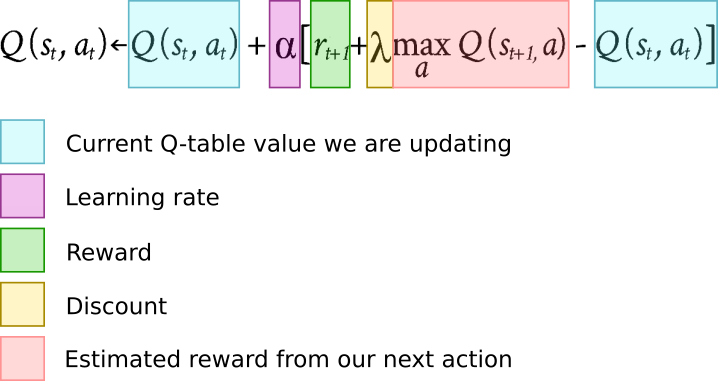



We want to store recieved Q values in q-table, however this is not efficient and is problematic for continious action spaces. The answer is parameterized value function e.g. with linear regression or neural network. 
In Q-learning the target is not given as in case of supervised learning, it depends on the prediction. So gradient descent is not true gradient desceent (it's "semi-gradient"). So the target doesn't say true Q value, just an estimate. 

In <b> Deep Q-learning </b> every transition (s, a, r, s', done) is saved in replay buffer / memory. So later on we can build prediction/target on that. It allows to train the model in batch size manner. For the gradient descent we don't take just the most recent transactiion, but sample for a batch from the replay buffer, calculate the target (based on the target network) and then perform gradient descent on sampled batch. There are in fact 2 networks: main Q networka and target Q network (stable copy of the main network copied every X steps during the simulation).
Deep Q-learning can be only used for discere action spaces, because each output node represents an action.

Paper: https://arxiv.org/abs/1312.5602

In [1]:
# !pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116

In [2]:
import os
import pprint
import random
import warnings
import numpy as np

from gym import Env
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy
import gym
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.env_util import make_vec_env

#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
model_path = os.path.join('Training', 'Saved Models', 'best_model_DQN')


warnings.filterwarnings("ignore")

Prepare the enviroment

In [3]:
# SIM PARAMETERS
SLA = 50
VM_TYPE1 = 7
VM_TYPE2 = 3
VM_TYPE3 = 1
PENALTY = 10000
STEPS = 250
ALPHA = 0.25
BETA = 0.75
SCENARIO = "Environment/Scenarios/train_DQN.txt"

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          penalty = PENALTY,
          steps = STEPS,
          scenario = SCENARIO,
          alpha = ALPHA,
          beta = BETA)

env = DummyVecEnv([lambda: env])
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

In [4]:
# PASSED THE TEST -> DO NOT REPEAT ANYMORE 
# check_env(env, warn=0, skip_render_check=1) 

In [5]:
copy_scenario('train', 'DQN', 200)
copy_scenario('test_scenario_1', 'DQN')
copy_scenario('test_scenario_2', 'DQN')
copy_scenario('test_scenario_3', 'DQN')
copy_scenario('test_scenario_4', 'DQN')
copy_scenario('test_scenario_5', 'DQN')

Train the model

In [6]:
model = DQN('MlpPolicy', env, verbose = 1, learning_rate=1e-3, gamma=0.99)
model.learn(total_timesteps=1000)

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 0        |
|    time_elapsed     | 1734     |
|    total_timesteps  | 1000     |
----------------------------------


In [7]:
model.save(model_path)

In [8]:
del model

In [9]:
model = DQN.load(model_path, env=env)

Evaluate the policy

In [10]:
#evaluate_policy(model, env, n_eval_episodes=10, render=True)

(9.78557977117598, 1.9206840421725435)

Test the model

In [11]:
STEPS = 50

info {'Quality of Service': 56.81016567301984, 'Current cost': 390, 'Request': 30.0, 'Timer': 0.5280745029449463, 'VM type I': 7, 'VM type II': 5, 'VM type III': 1}


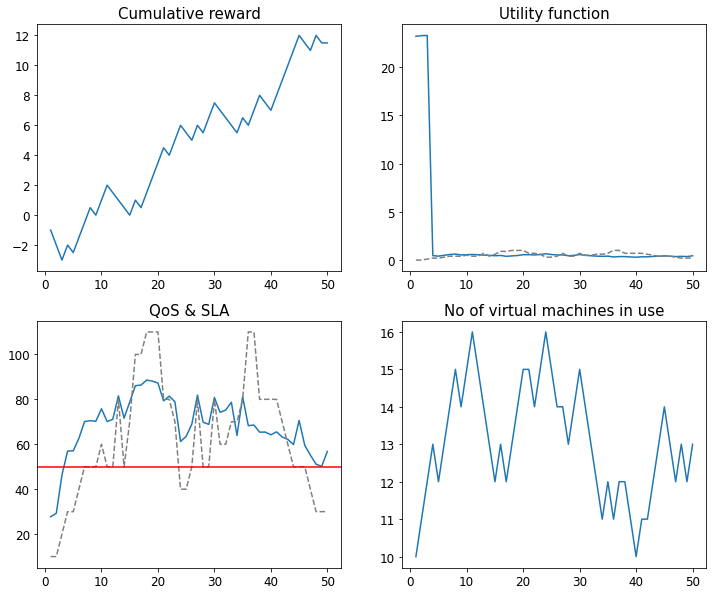

Cumulative reward at the end of the test:  11.5
Avg cost minus penalty per step:  1.83
Avg quality of service:  68.2
Avg no of virtual machines:  13.06


In [12]:
SCENARIO = 'Environment/Scenarios/test_scenario_1_DQN.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 71.88867972979526, 'Current cost': 275, 'Request': 170.0, 'Timer': 2.36476731300354, 'VM type I': 3, 'VM type II': 4, 'VM type III': 1}


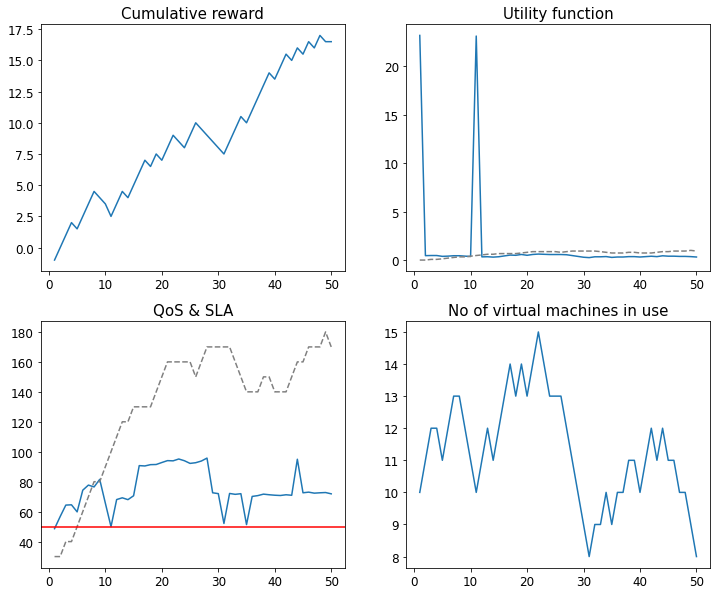

Cumulative reward at the end of the test:  16.5
Avg cost minus penalty per step:  1.32
Avg quality of service:  75.32
Avg no of virtual machines:  11.32


In [13]:
SCENARIO = 'Environment/Scenarios/test_scenario_2_DQN.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 45.079660218148675, 'Current cost': 310, 'Request': 20.0, 'Timer': 0.44365906715393066, 'VM type I': 10, 'VM type II': 1, 'VM type III': 1}


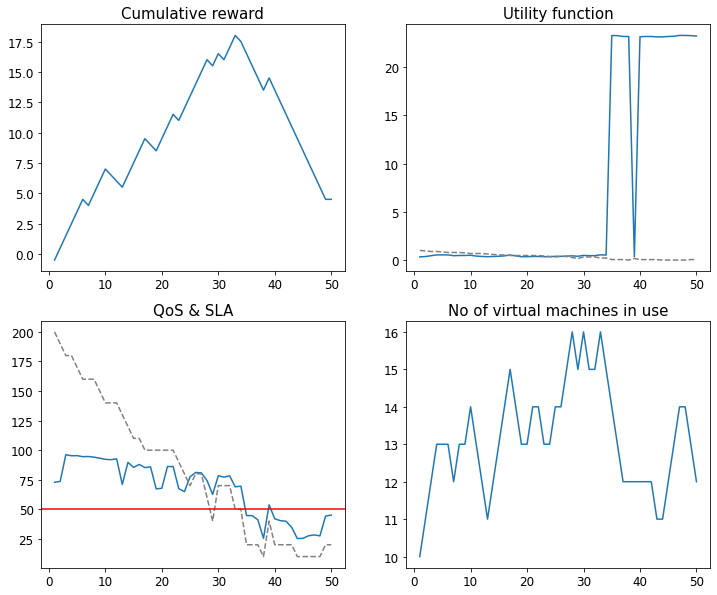

Cumulative reward at the end of the test:  4.5
Avg cost minus penalty per step:  7.26
Avg quality of service:  67.4
Avg no of virtual machines:  13.16


In [14]:
SCENARIO = 'Environment/Scenarios/test_scenario_3_DQN.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 44.18219357013441, 'Current cost': 495, 'Request': 20.0, 'Timer': 0.4526710510253906, 'VM type I': 3, 'VM type II': 6, 'VM type III': 3}


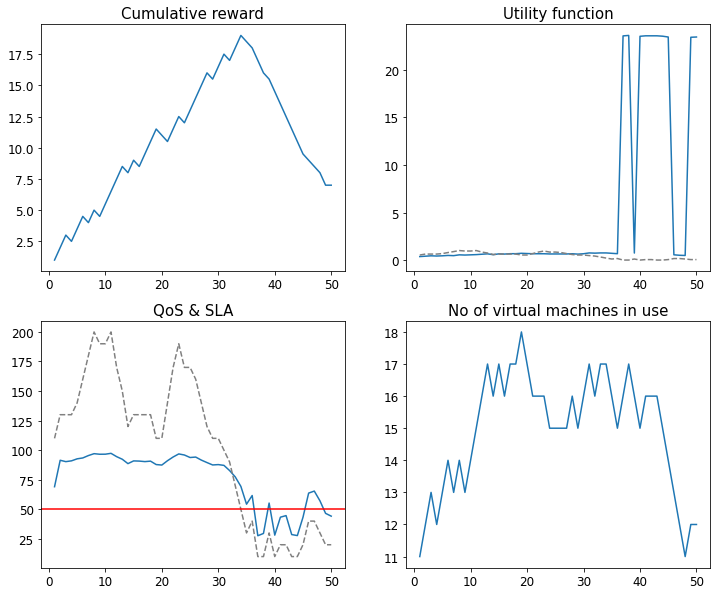

Cumulative reward at the end of the test:  7.0
Avg cost minus penalty per step:  5.19
Avg quality of service:  75.69
Avg no of virtual machines:  14.98


In [15]:
SCENARIO = 'Environment/Scenarios/test_scenario_4_DQN.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)

info {'Quality of Service': 93.96639710622712, 'Current cost': 625, 'Request': 170.0, 'Timer': 1.809157371520996, 'VM type I': 15, 'VM type II': 5, 'VM type III': 2}


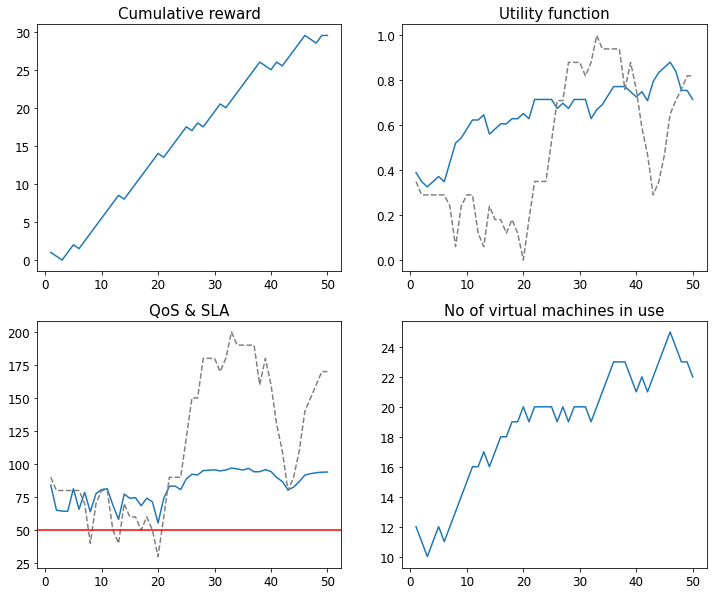

Cumulative reward at the end of the test:  29.5
Avg cost minus penalty per step:  0.65
Avg quality of service:  83.13
Avg no of virtual machines:  18.74


In [16]:
SCENARIO = 'Environment/Scenarios/test_scenario_5_DQN.txt'
test_model(SLA, VM_TYPE1, VM_TYPE2, VM_TYPE3, STEPS, SCENARIO, PENALTY, ALPHA, BETA, model)